# Part 3: Constant Maturity Swaps

In [1]:
# pip install QuantLib

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pylab as plt
from scipy.optimize import least_squares
from scipy.integrate import quad
import sympy as sp
# import warnings
# import pysabr
# from pysabr import Hagan2002LognormalSABR
# import QuantLib as ql

## Import Dataset (Similar to Part 2)

In [3]:
sheets = pd.ExcelFile('Swap and Swaption Markets_Amended.xlsx').sheet_names

In [4]:
df_swaption = pd.read_excel('Swap and Swaption Markets_Amended.xlsx', sheet_name=sheets[3], header = 2)
df_swaption

,Expiry,Tenor,-200bps,-150bps,-100bps,-50bps,-25bps,ATM,+25bps,+50bps,+100bps,+150bps,+200bps
0,1Y,1Y,91.570,62.030,44.130,31.224,26.182,22.50,20.96,21.40,24.34,27.488,30.297
1,1Y,2Y,83.270,61.240,46.570,35.807,31.712,28.72,27.12,26.84,28.51,31.025,33.523
2,1Y,3Y,73.920,56.870,44.770,35.745,32.317,29.78,28.29,27.80,28.77,30.725,32.833
3,1Y,5Y,55.190,44.640,36.510,30.242,27.851,26.07,24.98,24.56,25.12,26.536,28.165
4,1Y,10Y,41.180,35.040,30.207,26.619,25.351,24.47,23.98,23.82,24.25,25.204,26.355
5,5Y,1Y,67.800,49.090,38.400,31.485,29.060,27.26,26.04,25.32,24.94,25.320,25.980
6,5Y,2Y,57.880,46.410,39.033,33.653,31.531,29.83,28.56,27.65,26.71,26.540,26.760
7,5Y,3Y,53.430,44.440,38.180,33.437,31.536,29.98,28.76,27.82,26.67,26.200,26.150
8,5Y,5Y,41.990,36.524,32.326,29.005,27.677,26.60,25.73,25.02,24.06,23.570,23.400
9,5Y,10Y,34.417,30.948,28.148,25.954,25.136,24.51,23.99,23.56,22.91,22.490,22.250


Notes on Swaption Data on first inspection:
* This is lognormal Implied Vol for SOFR Swaptions
* Convection for bps strike is (Forward + Basis Point)

In [5]:
def convert_tenor_to_numeric(series):
    num = series.str.slice(stop = -1).astype(int)
    freq = series.str.slice(start = -1)

    conditions = [freq.str.upper() == 'M', freq.str.upper() == 'Y']
    choices = [num * 30 / 360, num.astype(float)]

    return pd.Series(np.select(conditions, choices, default=np.nan), name=series.name)

In [6]:
def convert_bps_to_numeric(column_series):

    column_names = column_series.str.slice(stop = -3)
    replaced_list = []

    for col in column_names:
        if col == '':
            replaced_list.append(0.0)
        else:
            replaced_list.append(float(col) / 10000)
    
    return replaced_list  

In [7]:
# Extract the expiry and tenor information from the column names and convert them to numeric values
# Imp vol is calculated in percentages, so we need to divide by 100 to get the decimal form
# bps is defined as 1/100 of a percentage point, so we need to divide by 10000 to get the decimal form

df_timings = pd.concat([convert_tenor_to_numeric(df_swaption['Expiry']), convert_tenor_to_numeric(df_swaption['Tenor'])], axis=1)
df_bps = df_swaption.drop(columns = ['Expiry', 'Tenor']) / 100  # e.g. 22.5 -> 0.225
df_bps.columns = convert_bps_to_numeric(df_bps.columns)

display(pd.concat([df_timings, df_bps], axis=1))

,Expiry,Tenor,-0.02,-0.015,-0.01,-0.005,-0.0025,0.0,0.0025,0.005,0.01,0.015,0.02
0,1.0,1.0,0.91570,0.62030,0.44130,0.31224,0.26182,0.2250,0.2096,0.2140,0.2434,0.27488,0.30297
1,1.0,2.0,0.83270,0.61240,0.46570,0.35807,0.31712,0.2872,0.2712,0.2684,0.2851,0.31025,0.33523
2,1.0,3.0,0.73920,0.56870,0.44770,0.35745,0.32317,0.2978,0.2829,0.2780,0.2877,0.30725,0.32833
3,1.0,5.0,0.55190,0.44640,0.36510,0.30242,0.27851,0.2607,0.2498,0.2456,0.2512,0.26536,0.28165
4,1.0,10.0,0.41180,0.35040,0.30207,0.26619,0.25351,0.2447,0.2398,0.2382,0.2425,0.25204,0.26355
5,5.0,1.0,0.67800,0.49090,0.38400,0.31485,0.29060,0.2726,0.2604,0.2532,0.2494,0.25320,0.25980
6,5.0,2.0,0.57880,0.46410,0.39033,0.33653,0.31531,0.2983,0.2856,0.2765,0.2671,0.26540,0.26760
7,5.0,3.0,0.53430,0.44440,0.38180,0.33437,0.31536,0.2998,0.2876,0.2782,0.2667,0.26200,0.26150
8,5.0,5.0,0.41990,0.36524,0.32326,0.29005,0.27677,0.2660,0.2573,0.2502,0.2406,0.23570,0.23400
9,5.0,10.0,0.34417,0.30948,0.28148,0.25954,0.25136,0.2451,0.2399,0.2356,0.2291,0.22490,0.22250


We have to pull back the discount factors to calculate annuities. We will use the OIS backcalculated swap discount rates for now

$$
A_{n+1,N}(t) = \sum^{N}_{i=n+1} \Delta_{i-1} D_{i}(t)
$$

$$
\therefore A_{n+1,N}(0) = \sum^{N}_{i=n+1} \Delta_{i-1} D_{i}(0) = \sum^{N}_{i=n+1} \Delta_{i-1} D(0,T_i)
$$

In [8]:
ois_discount_factors = pd.read_csv('ois_sofr_discounted_factors.csv', index_col=0)
ois_discount_factors = ois_discount_factors.drop(columns = 'Market Rate')
ois_discount_factors = ois_discount_factors.loc[round(ois_discount_factors['Tenor_Year_Numeric']) == ois_discount_factors['Tenor_Year_Numeric']].reset_index(drop = True)
display(ois_discount_factors.head(), ois_discount_factors.tail(1))

,Tenor_Year_Numeric,Discount Factor
0,1.0,0.966224
1,2.0,0.935300
2,3.0,0.903758
3,4.0,0.871806
4,5.0,0.839750


,Tenor_Year_Numeric,Discount Factor
29,30.0,0.289438


In [9]:
# Calculate Annuities
# Discount Factor Table is annual frequency!

def calculate_annuities(df_timings, discount_factors):

    annuity =\
    (
        pd.Series(
                    np.zeros(len(df_timings)),
                    name = 'Annuities'
                )
    )

    for row in df_timings.itertuples():
        annuity[row.Index] = np.sum(discount_factors[int(row[1]):int(row[1]+row[2])])

    return annuity

In [10]:
df_annuities = calculate_annuities(df_timings, ois_discount_factors['Discount Factor'])
pd.concat([df_timings, df_annuities, df_bps], axis = 1)

,Expiry,Tenor,Annuities,-0.02,-0.015,-0.01,-0.005,-0.0025,0.0,0.0025,0.005,0.01,0.015,0.02
0,1.0,1.0,0.935300,0.91570,0.62030,0.44130,0.31224,0.26182,0.2250,0.2096,0.2140,0.2434,0.27488,0.30297
1,1.0,2.0,1.839058,0.83270,0.61240,0.46570,0.35807,0.31712,0.2872,0.2712,0.2684,0.2851,0.31025,0.33523
2,1.0,3.0,2.710864,0.73920,0.56870,0.44770,0.35745,0.32317,0.2978,0.2829,0.2780,0.2877,0.30725,0.32833
3,1.0,5.0,4.358245,0.55190,0.44640,0.36510,0.30242,0.27851,0.2607,0.2498,0.2456,0.2512,0.26536,0.28165
4,1.0,10.0,7.930389,0.41180,0.35040,0.30207,0.26619,0.25351,0.2447,0.2398,0.2382,0.2425,0.25204,0.26355
5,5.0,1.0,0.807631,0.67800,0.49090,0.38400,0.31485,0.29060,0.2726,0.2604,0.2532,0.2494,0.25320,0.25980
6,5.0,2.0,1.583386,0.57880,0.46410,0.39033,0.33653,0.31531,0.2983,0.2856,0.2765,0.2671,0.26540,0.26760
7,5.0,3.0,2.327821,0.53430,0.44440,0.38180,0.33437,0.31536,0.2998,0.2876,0.2782,0.2667,0.26200,0.26150
8,5.0,5.0,3.725251,0.41990,0.36524,0.32326,0.29005,0.27677,0.2660,0.2573,0.2502,0.2406,0.23570,0.23400
9,5.0,10.0,6.723663,0.34417,0.30948,0.28148,0.25954,0.25136,0.2451,0.2399,0.2356,0.2291,0.22490,0.22250


The Forward Prices at time 0 for swaps can also be calculated
$$
S_{n,N}(t) = \frac{D_n(t) - D_N(t)}{A_{n+1,N}}
$$

$$
\therefore S_{n,N}(0) = \frac{D_n(0) - D_N(0)}{A_{n+1,N}} = \frac{D(0,T_n) - D(0,T_N)}{A_{n+1,N}}
$$

In [11]:
# Calculate Forward Rates
# Discount Factors is on annual basis

def calculate_forward_rates(df_timings, annuities, discount_factors):

    df_timings = df_timings.astype(int)

    forward_rates =\
    (
        pd
        .Series(np.full(len(df_annuities), np.nan),
                name = "Forward")
    )

    for row in df_timings.itertuples():
        forward_rates[row.Index] = (discount_factors.iloc[row[1]] - discount_factors.iloc[row[1]+row[2]]) / annuities[row.Index]

    return forward_rates

In [12]:
df_forward_rates = calculate_forward_rates(df_timings, df_annuities, ois_discount_factors['Discount Factor'])

In [13]:
pd.concat([df_timings, df_annuities, df_forward_rates, df_bps], axis = 1)

,Expiry,Tenor,Annuities,Forward,-0.02,-0.015,-0.01,-0.005,-0.0025,0.0,0.0025,0.005,0.01,0.015,0.02
0,1.0,1.0,0.935300,0.033724,0.91570,0.62030,0.44130,0.31224,0.26182,0.2250,0.2096,0.2140,0.2434,0.27488,0.30297
1,1.0,2.0,1.839058,0.034525,0.83270,0.61240,0.46570,0.35807,0.31712,0.2872,0.2712,0.2684,0.2851,0.31025,0.33523
2,1.0,3.0,2.710864,0.035247,0.73920,0.56870,0.44770,0.35745,0.32317,0.2978,0.2829,0.2780,0.2877,0.30725,0.32833
3,1.0,5.0,4.358245,0.036608,0.55190,0.44640,0.36510,0.30242,0.27851,0.2607,0.2498,0.2456,0.2512,0.26536,0.28165
4,1.0,10.0,7.930389,0.039007,0.41180,0.35040,0.30207,0.26619,0.25351,0.2447,0.2398,0.2382,0.2425,0.25204,0.26355
5,5.0,1.0,0.807631,0.039468,0.67800,0.49090,0.38400,0.31485,0.29060,0.2726,0.2604,0.2532,0.2494,0.25320,0.25980
6,5.0,2.0,1.583386,0.039911,0.57880,0.46410,0.39033,0.33653,0.31531,0.2983,0.2856,0.2765,0.2671,0.26540,0.26760
7,5.0,3.0,2.327821,0.040339,0.53430,0.44440,0.38180,0.33437,0.31536,0.2998,0.2876,0.2782,0.2667,0.26200,0.26150
8,5.0,5.0,3.725251,0.041100,0.41990,0.36524,0.32326,0.29005,0.27677,0.2660,0.2573,0.2502,0.2406,0.23570,0.23400
9,5.0,10.0,6.723663,0.042281,0.34417,0.30948,0.28148,0.25954,0.25136,0.2451,0.2399,0.2356,0.2291,0.22490,0.22250


We can also output the actual prices of the swaptions using the Black Scholes Lognormal model, which is the same as the Black76 model for swaptions.

In [14]:
## Default Functions for Black Scholes Lognormal Model. 
## In the event of a Black76 model, set S = F and r = 0.0.
## If there is dividend, set r = r-q where q is the dividend yield.
## Functions need to be paired with annuities and forward rates to get swaption prices

def BlackScholesLognormalPayer(S, K, r, sigma, T):
    d1 = (np.log(S/K)+(r+sigma**2/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)


def BlackScholesLognormalReceiver(S, K, r, sigma, T):
    d1 = (np.log(S/K)+(r+sigma**2/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

In [15]:
def calculate_prices(df_bps, df_timings, df_forward_rates, df_annuities):
    F = df_forward_rates
    annuity = df_annuities
    r = 0.0          # Black76 discounting convention

    strike_shifts = df_bps.columns.astype(float).to_list()
    T_vec = df_timings['Expiry'].astype(float).values

    payer_strike_shifts = [shift for shift in strike_shifts if shift >= 0]
    receiver_strike_shifts = [shift for shift in strike_shifts if shift < 0]

    # print(payer_strike_shifts, receiver_strike_shifts)

    payer_prices = pd.DataFrame(index=df_bps.index, columns=strike_shifts, dtype=float).drop(columns = receiver_strike_shifts)
    receiver_prices = pd.DataFrame(index=df_bps.index, columns=strike_shifts, dtype=float).drop(columns = payer_strike_shifts)

    for shift in payer_strike_shifts:
        K = F + shift
        vols = df_bps[shift].astype(float).values

        # print(vols)

        payer_prices[shift] = annuity * BlackScholesLognormalPayer(F, K, r, vols, T_vec)


    for shift in receiver_strike_shifts:
        K = F + shift
        vols = df_bps[shift].astype(float).values

        receiver_prices[shift] = annuity * BlackScholesLognormalReceiver(F, K, r, vols, T_vec)


    return payer_prices, receiver_prices, pd.concat([df_timings, receiver_prices, payer_prices], axis=1)

In [16]:
# Attach expiry/tenor for readability
payer_swaption_prices, receiver_swaption_prices, df_swaption_prices = calculate_prices(df_bps, df_timings, df_forward_rates, df_annuities)
display(df_swaption_prices)

,Expiry,Tenor,-0.02,-0.015,-0.01,-0.005,-0.0025,0.0,0.0025,0.005,0.01,0.015,0.02
0,1.0,1.0,0.001488,0.001299,0.001391,0.001748,0.002129,0.002825,0.001718,0.001128,0.000637,0.000434,0.000322
1,1.0,2.0,0.002504,0.002696,0.003306,0.004547,0.005624,0.007250,0.005031,0.003568,0.002081,0.001416,0.001053
2,1.0,3.0,0.002850,0.003509,0.004719,0.006936,0.008744,0.011310,0.008063,0.005789,0.003294,0.002142,0.001527
3,1.0,5.0,0.001971,0.003138,0.005178,0.009016,0.012162,0.016546,0.011519,0.007961,0.004033,0.002303,0.001457
4,1.0,10.0,0.001430,0.003186,0.006916,0.014780,0.021308,0.030123,0.021567,0.015273,0.007791,0.004235,0.002482
5,5.0,1.0,0.006146,0.005593,0.005707,0.006342,0.006892,0.007633,0.006564,0.005698,0.004468,0.003681,0.003141
6,5.0,2.0,0.009677,0.010296,0.011676,0.013675,0.014957,0.016510,0.014419,0.012632,0.009895,0.008016,0.006691
7,5.0,3.0,0.012778,0.014461,0.016950,0.020236,0.022267,0.024651,0.021610,0.018949,0.014732,0.011710,0.009549
8,5.0,5.0,0.013594,0.017272,0.021973,0.027953,0.031598,0.035802,0.031244,0.027201,0.020652,0.015856,0.012393
9,5.0,10.0,0.017247,0.024435,0.033681,0.045648,0.052999,0.061387,0.053835,0.047115,0.035946,0.027425,0.021045


## CMS Products - Key Differences:

1. **Underlying**: CMS products are based on the swap rate, which is an average of forward rates over a specified period. In contrast, caplets and floorlets are based on a single forward rate at a specific time.
2. **Payoff Structure**: CMS products typically have a payoff that depends on the average swap rate over a period, while caplets and floorlets have payoffs that depend on the forward rate at a specific time.
3. **Volatility Modeling**: The volatility structure for CMS products can be more complex due to the averaging of rates, while caplets and floorlets can be modeled using simpler volatility structures.
4. **Calibration**: Calibrating models for CMS products may require more sophisticated techniques due to the complexity of the underlying swap rate, while caplets and floorlets can often be calibrated using standard methods.

Calculating the CMS rate payment for swap rate $S_{n,N}(T)$ at time T can be valued as, where $F = S_{n,N}(0)$

$$
D(0,T) F + \int_{0}^F h''(K) V^{rec}(K) dK +  \int_F^\infty h''(K) V^{pay}(K) dK
$$

Where
$$
h''(K) = \frac{-IRR''(K) \cdot K - 2\cdot IRR'(K)}{IRR(K)^2} + \frac{2\cdot IRR'(K)^2 \cdot K}{IRR(K)^3}
$$

## Pricing IRR Swaptions for CMS valuation based on SABR Model 

The price of a IRR swaption can be given as:

$$
V_{n,N}(0) \approx D(0,T) \cdot IRR(S_{n,N}(0)) \cdot Black(S_{n,N}(0), K, \sigma_{n,N}, T)
$$

Where
$$
\text{IRR}_{\text{closed}}(S) = \sum_{i=1}^{(T_N-T_n) \times m} \frac{1/m}{(1+S/m)^i}
$$

Given that it is a summation series of a geometric series, we can find a closed form solution
$$\text{IRR}_{\text{closed}}(S) = \frac{\left(S + m\right)^{1 - T} \left(- m^{T} + \left(S + m\right)^{T}\right)}{S m}$$


Take a first and second derivative to obtain the IRR'(S) and IRR''(S): <br/>


**First Derivative:**
$$
\text{IRR'(S)} 
= \frac{N \left(S + m\right)^{- 2 N} \left(S m + m^{2}\right)^{N}}{S \left(S + m\right)} + \frac{m^{N} \left(S + m\right)^{- N}}{S^{2}} - \frac{1}{S^{2}}

$$

**Second Derivative:**
$$
\text{IRR''(S)} 
= \frac{N^{2} \left(S + m\right)^{- 2 N} \left(S m + m^{2}\right)^{N}}{S \left(S + m\right)^{2}} - \frac{N \left(S + m\right)^{- 2 N} \left(S m + m^{2}\right)^{N}}{S \left(S + m\right)^{2}} - \frac{N m^{N} \left(S + m\right)^{- N}}{S^{2} \left(S + m\right)} - \frac{N \left(S + m\right)^{- 2 N} \left(S m + m^{2}\right) \left(S m + m^{2}\right)^{N}}{S^{2} m \left(S + m\right)^{2}} - \frac{2 m^{N} \left(S + m\right)^{- N}}{S^{3}} + \frac{2}{S^{3}}
$$

In [17]:
def compute_irr_derivatives():
    """
    Compute first and second derivatives of IRR(S) with respect to S
    IRR(S) = Σ(i=1 to T) (1/m) / (1+S/m)^i
    """
    # Define symbols
    S, m, i, N = sp.symbols('S m i N', real=True, positive=True)
    
    # Define the IRR function as a summation
    # Using finite summation from i=1 to N
    irr_expr = sp.Sum(1/m / (1 + S/m)**i, (i, 1, N))
    
    # Evaluate the summation (closed form for geometric series)
    irr_closed = (1/S) * (1 - (m/(m+S))**N)
    irr_simplified = sp.simplify(irr_closed)
    # irr_simplified = irr_closed

    
    print("IRR(S) Expression:")
    print(f"Original: {irr_expr}")
    print(f"Closed Form: {irr_simplified}")
    
    # Compute first derivative
    first_derivative = sp.diff(irr_simplified, S)
    first_derivative_simplified = sp.simplify(first_derivative)
    
    print(f"\nFirst Derivative (dIRR/dS):")
    print(first_derivative_simplified)
    
    # Compute second derivative
    second_derivative = sp.diff(first_derivative_simplified, S)
    second_derivative_simplified = sp.simplify(second_derivative)
    
    print(f"\nSecond Derivative (d²IRR/dS²):")
    print(second_derivative_simplified)

    # Compute h''(K) for static replication:
    h_double_prime = (-second_derivative_simplified * S - 2 * first_derivative_simplified) / irr_simplified**2 + 2 * (first_derivative_simplified**2) * S / irr_simplified**3
    h_double_prime_simplified = sp.simplify(h_double_prime)

    print(f"\nh_double_prime:")
    print(h_double_prime_simplified)

    
    # Return numpy expressions for numerical evaluation
    irr_func = sp.lambdify((S, m, N), irr_simplified, 'numpy')
    d_irr_func = sp.lambdify((S, m, N), first_derivative_simplified, 'numpy')
    d2_irr_func = sp.lambdify((S, m, N), second_derivative_simplified, 'numpy')
    h_double_prime_func = sp.lambdify((S, m, N), h_double_prime_simplified, 'numpy')


    print(f"\n numpy functions generated")

    return irr_func, d_irr_func, d2_irr_func, h_double_prime_func

In [18]:
# Run the function
irr_func, d_irr_func, d2_irr_func, h_double_prime_func = compute_irr_derivatives()

IRR(S) Expression:
Original: Sum(1/(m*(S/m + 1)**i), (i, 1, N))
Closed Form: -m**N/(S*(S + m)**N) + 1/S

First Derivative (dIRR/dS):
N*(S*m + m**2)**N/(S*(S + m)*(S + m)**(2*N)) + m**N/(S**2*(S + m)**N) - 1/S**2

Second Derivative (d²IRR/dS²):
-N**2*(S*m + m**2)**N/(S*(S + m)**2*(S + m)**(2*N)) - N*(S*m + m**2)**N/(S*(S + m)**2*(S + m)**(2*N)) - N*m**N/(S**2*(S + m)*(S + m)**N) - N*(S*m + m**2)*(S*m + m**2)**N/(S**2*m*(S + m)**2*(S + m)**(2*N)) - 2*m**N/(S**3*(S + m)**N) + 2/S**3

h_double_prime:
(S + m)**(-10*N - 8)*(-2*m*(S + m)**(9*N + 6)*(N*S*(m*(S + m))**N + m**N*(S + m)**(N + 1) - (S + m)**(2*N + 1))**2 + (S + m)**(3*N + 2)*(m**N - (S + m)**N)*(-2*N*S*m*(m*(S + m))**N*(S + m)**(7*N + 5) + 2*m*(S + m)**(9*N + 6) - 2*m**(N + 1)*(S + m)**(8*N + 6) + (S + m)**(3*N + 1)*(N*S**2*m*(m*(S + m))**N*(N + 1)*(S + m)**(4*N + 3) + N*S*m**(N + 1)*(S + m)**(5*N + 4) + N*S*(m*(S + m))**(N + 1)*(S + m)**(4*N + 3) - 2*m*(S + m)**(6*N + 5) + 2*m**(N + 1)*(S + m)**(5*N + 5))))/(m*(m**N - (S + m)**N)

### For Generating Latex Form

In [19]:
# # Generate LaTeX representations
# S, m, i, N = sp.symbols('S m i N', real=True, positive=True)

# irr_latex = sp.latex(irr)
# irr_prime_latex = sp.latex(irr_prime)
# irr_double_prime_latex = sp.latex(irr_double_prime)

# # Also get the original expression
# original_expr = sp.Sum(1/m / (1 + S/m)**i, (i, 1, N))
# original_latex = sp.latex(original_expr)

# print("LaTeX Representations:")
# print(f"\nOriginal (Summation Form):\n{original_latex}")
# print(f"\nClosed Form:\n{irr_latex}")
# print(f"\nFirst Derivative:\n{irr_prime_latex}")
# print(f"\nSecond Derivative:\n{irr_double_prime_latex}")

## SABR Model Revisited

The implied Black volatility of the SABR model is given below, where $\beta = 0.75$ as a default setting

$$
    \begin{split}
      \sigma_{SABR}(F_0, K, \alpha, \beta, \rho, \nu)
      = \frac{\alpha}{(F_0K)^{(1-\beta)/2}\left\{ 1 + \frac{(1-\beta)^2}{24}\log^2\left(\frac{F_0}{K}\right) + \frac{(1-\beta)^4}{1920}\log^4\left(\frac{F_0}{K}\right) + \cdots\right\} }
      \times \frac{z}{x(z)} \times \left\{ 1 + \left[
           \frac{(1-\beta)^2}{24}
           \frac{\alpha^2}{(F_0K)^{1-\beta}}+\frac{1}{4}\frac{\rho\beta\nu\alpha}{(F_0K)^{(1-\beta)/2}}+\frac{2-3\rho^2}{24}\nu^2\right]
         T + \cdots \right.
    \end{split}
$$

where

$$
    \begin{split}
      z = \frac{\nu}{\alpha} (F_0K)^{(1-\beta)/2}
      \log\left(\frac{F_0}{K}\right),
    \end{split}
$$

and

$$
    % \begin{split}
      x(z) = \log \left[ \frac{\sqrt{1-2\rho z+z^2}+z -\rho}{1-\rho}
      \right].
    % \end{split}
$$

The definition above contains the function

$$
\begin{split}
{SABR}(F, K, T, \alpha, \beta, \rho, \nu)
\end{split}
$$


### Functions

In [20]:
def SABR(F, K, T, alpha, beta, rho, nu):
    X = K
    # if K is at-the-money-forward
    if abs(F - K) < 1e-12:
        numer1 = (((1 - beta)**2)/24)*alpha*alpha/(F**(2 - 2*beta))
        numer2 = 0.25*rho*beta*nu*alpha/(F**(1 - beta))
        numer3 = ((2 - 3*rho*rho)/24)*nu*nu
        VolAtm = alpha*(1 + (numer1 + numer2 + numer3)*T)/(F**(1-beta))
        sabrsigma = VolAtm
    else:
        z = (nu/alpha)*((F*X)**(0.5*(1-beta)))*np.log(F/X)
        zhi = np.log((((1 - 2*rho*z + z*z)**0.5) + z - rho)/(1 - rho))
        numer1 = (((1 - beta)**2)/24)*((alpha*alpha)/((F*X)**(1 - beta)))
        numer2 = 0.25*rho*beta*nu*alpha/((F*X)**((1 - beta)/2))
        numer3 = ((2 - 3*rho*rho)/24)*nu*nu
        numer = alpha*(1 + (numer1 + numer2 + numer3)*T)*z
        denom1 = ((1 - beta)**2/24)*(np.log(F/X))**2
        denom2 = (((1 - beta)**4)/1920)*((np.log(F/X))**4)
        denom = ((F*X)**((1 - beta)/2))*(1 + denom1 + denom2)*zhi
        sabrsigma = numer/denom

    return sabrsigma

In [21]:
## The following functions are needed together with annuities and forward rates to calculate the integrands for the payer and receiver swaption prices under the SABR model.

def SABRPayer(F, K, r, alpha, beta, rho, nu, T, irr_input):
    sabr_vol = SABR(F, K, T, alpha, beta, rho, nu)
    return irr_input * BlackScholesLognormalPayer(F, K, r, sabr_vol, T)


def SABRReceiver(F, K, r, alpha, beta, rho, nu, T, irr_input):
    sabr_vol = SABR(F, K, T, alpha, beta, rho, nu)
    return irr_input * BlackScholesLognormalReceiver(F, K, r, sabr_vol, T)


def sabrPayerintegrand(K, F, r, T, alpha, beta, rho, nu, irr_input):
    price = SABRPayer(F, K, r, alpha, beta, rho, nu, T, irr_input)
    return price


def sabrReceiverintegrand(K, F, r, T, alpha, beta, rho, nu, irr_input):
    price = SABRReceiver(F, K, r, alpha, beta, rho, nu, T, irr_input)  
    return price

In [22]:
# S = 0.33
# r = 0.0
# N = 1.0
# alpha = .000910
# beta = 0.75
# rho = -.622993
# nu = .023245
# F = .033724
# I_put = quad(lambda x: sabrReceiverintegrand(x, S, r, N, alpha, beta, rho, nu), 1e-6, F)
# I_call = quad(lambda x: sabrPayerintegrand(x, S, r, N, alpha, beta, rho, nu), F, 2000)
# E_var = 2*np.exp(r*N)*(I_put[0] + I_call[0])
# print('The expected integrated variance is: %.9f' % E_var)

## Known Results from Part 2:

We have already established the calibrated results from Part II, so we can use it to price our options using the Black Model as a reporting model <br>
We also have the OIS discounting factors from Part I, so we can output a similar technique too

In [23]:
sabr_calibration_results = pd.read_csv('sabr_calibration_results.csv')

In [24]:
sabr_calibration_results.head()

,Expiry,Tenor,Forward,alpha,rho,nu
0,1.0,1.0,0.033724,0.000910,-0.622993,0.023245
1,1.0,2.0,0.034525,0.001214,-0.499492,0.018643
2,1.0,3.0,0.035247,0.001278,-0.451604,0.015668
3,1.0,5.0,0.036608,0.001137,-0.377649,0.011376
4,1.0,10.0,0.039007,0.001087,-0.206444,0.008073


In [25]:
pd.read_csv('ois_sofr_discounted_factors.csv').head()

,Unnamed: 0,Tenor_Year_Numeric,Market Rate,Discount Factor
0,0,0.5,0.036161,0.982241
1,1,1.0,0.034957,0.966224
2,2,1.5,0.034112,0.950930
3,3,2.0,0.034009,0.935300
4,4,2.5,0.034158,0.919460


## Calculating SABR model Present Values

For each CMS leg, the calculation of the swap rate is as presented below, statically replicated: <br>
The function for $h''(K)$ has already been outputed via SymPy

The convexity correction is the expected difference in value between the forward swap rate and the CMS rate

$$V_0 = D(0,T) \cdot F + \int_0^F h''(K) V^{rec}(K) dK + \int_0^F h''(K) V^{pay}(K) dK
$$

The functions for $V^{rec}$ and $V^{pay}$ are defined with SABR-model implied vol outputted to Black Prices <br>


$$
V_{pay} = [IRR(S_{n,N}(T))(S_{n,N}(T)-K)^+]
$$

$$
V_{receive} = [IRR(S_{n,N}(T))(K - S_{n,N}(T))^+]
$$
$$
\text{**Note: The Value of the CMS rate payment is valued at time 0**}
$$

In [26]:
def interpolate_sabr_parameters(sabr_calibration_results, expiry_series, multiple):

    sabr_calibration_results.index = np.asarray(expiry_series)

    sabr_calibration_results = sabr_calibration_results.reindex(np.arange(0+multiple, expiry_series.max()+multiple, multiple))
    sabr_calibration_results = sabr_calibration_results.interpolate(method='index').reset_index(drop = True)
    # sabr_calibration_results.iloc[0, :] = sabr_calibration_results.iloc[1,:] - (sabr_calibration_results.iloc[2,:] - sabr_calibration_results.iloc[1,:])
    sabr_calibration_results = sabr_calibration_results.interpolate(method='slinear', fill_value = 'extrapolate', limit_direction='backward')

    return sabr_calibration_results

In [27]:
def interpolate_tenors(df, tenor_series, rate_series, multiple):
    df.index = np.asarray(tenor_series)

    tenor_col_name = tenor_series.name
    rate_name = rate_series.name

    df = df.reindex(np.arange(0+multiple, tenor_series.iloc[-1]+multiple, multiple))

    ## Initial positions cannot be interpolated, so use slinear to calibrate this
    df= df.interpolate(method = 'slinear', fill_value = 'extrapolate', limit_direction='both')

    return df


## Recreate the Tenor since we need T = [0,50]:

def calculate_ois_sofr_discount_factors(tenor_year, rates):

    discount_array = np.full(len(tenor_year), np.nan)

    # Bootstrap the Curve

    condition = (tenor_year <= 1.0)
    # choices = [1 / (1 + tenor_year*rates), 1 / (1 + rates)**tenor_year]

    discount_array = np.where(condition, 1 / (1 + tenor_year*rates), 1 / (1 + rates)**tenor_year)
    
    return pd.DataFrame(
                        {'Tenor_Year_Numeric': tenor_year,
                         'Market Rate': rates,
                         'Discount Factor': discount_array
                        }
                        )

In [28]:
def calculate_PV(sabr_calibration_results, sabr_calibration_index, discount=1.0):

    # discount = 0.966224
    exp, tenor, forward, alpha, rho, nu = sabr_calibration_results.iloc[sabr_calibration_index]
    m = 1
    N = tenor+exp
    n = exp
    tot = (N-n) * m
           
    irr = irr_func(forward, m, tot)

    v_pay_sum = quad(lambda x: h_double_prime_func(x, m, tot) * discount * sabrPayerintegrand(x, forward, 0.0, N, alpha, 0.75, rho, nu, irr), forward, 150)
    v_rec_sum = quad(lambda x: h_double_prime_func(x, m, tot) * discount * sabrReceiverintegrand(forward, x, 0.0, N, alpha, 0.75, rho, nu, irr), 1e-4, forward)

    forward_PV = forward * discount
    CMS_PV = forward*discount + v_rec_sum[0] + v_pay_sum[0]
    difference = round(v_rec_sum[0]+v_pay_sum[0],5)

    return forward_PV, CMS_PV, difference

In [29]:
def tabulate_forwards_and_CMS_PVs(sabr_calibration_results, ois_discount_factors):

    results = []

    for i in range(len(sabr_calibration_results)):
        forward_PV, CMS_PV, difference = calculate_PV(sabr_calibration_results, i, ois_discount_factors['Discount Factor'].iloc[i])
        results.append((forward_PV, CMS_PV, difference))

    return pd.DataFrame(results, columns=['Forward PV', 'CMS PV', 'Difference'])

## Part 1: PV Leg of CMS 10y semi-annually over next 5 years

There are 2 ways to fit the SABR model given limited information:
1. Interpolate each implied vol and then calibrating SABR accordingly
2. With the given SABR parameters, interpolate linearly.

We will take the 2nd approach here for simplicity

With the interpolated parameters, we can recalculate the Black prices from SABR-model implied vols, and following the workflow described below

1. Find the CMS 10Y for the first payment at the first expiry
2. Repeat step one up to a period of 5 years (i.e.: 10 payments)
3. Discount all payments to the present

### A: PV Leg of CMS 10y semi-annually over next 5 years

In [30]:
sabr_calibration_results_10y = sabr_calibration_results.loc[(sabr_calibration_results['Tenor'] == 10) & (sabr_calibration_results['Expiry'] <= 5.0)].reset_index(drop = True)
sabr_calibration_results_10y = interpolate_sabr_parameters(sabr_calibration_results_10y, sabr_calibration_results_10y['Expiry'], 0.5)

sabr_calibration_results_10y.head(3)

,Expiry,Tenor,Forward,alpha,rho,nu
0,0.5,10.0,0.038598,0.001084,-0.187758,0.008502
1,1.0,10.0,0.039007,0.001087,-0.206444,0.008073
2,1.5,10.0,0.039416,0.001090,-0.225130,0.007644


In [31]:
ois_discounts = pd.read_csv("ois_sofr_discounted_factors.csv", index_col = 0)
ois_discounts_semi_annual = ois_discounts.loc[ois_discounts['Tenor_Year_Numeric'] <= 5.0]

ois_discounts_semi_annual.head(2)

,Tenor_Year_Numeric,Market Rate,Discount Factor
0,0.5,0.036161,0.982241
1,1.0,0.034957,0.966224


In [32]:
df_cms_10y = pd.concat(
    [
        sabr_calibration_results_10y[['Expiry', 'Tenor']],
        tabulate_forwards_and_CMS_PVs(sabr_calibration_results_10y, ois_discounts_semi_annual)
    ],
    axis=1
).sort_values(['Expiry', 'Tenor'])

In [33]:
df_cms_10y['CMS PV'].sum()

np.float64(0.4377908891416789)

### B: PV Leg of CMS 2y quarterly over next 10 years

In [34]:
sabr_calibration_results_2y = sabr_calibration_results.loc[(sabr_calibration_results['Tenor'] == 2) & (sabr_calibration_results['Expiry'] <= 10.0)].reset_index(drop = True)
sabr_calibration_results_2y = sabr_calibration_results.loc[(sabr_calibration_results['Tenor'] == 2) & (sabr_calibration_results['Expiry'] <= 10.0)].reset_index(drop = True)
sabr_calibration_results_2y = interpolate_sabr_parameters(sabr_calibration_results_2y, sabr_calibration_results_2y['Expiry'], 0.25)
sabr_calibration_results_2y.tail()

,Expiry,Tenor,Forward,alpha,rho,nu
35,9.00,2.0,0.042782,0.001314,-0.574275,0.010761
36,9.25,2.0,0.042962,0.001320,-0.556367,0.010493
37,9.50,2.0,0.043141,0.001325,-0.538459,0.010224
38,9.75,2.0,0.043320,0.001330,-0.520550,0.009956
39,10.00,2.0,0.043500,0.001336,-0.502642,0.009687


In [35]:
ois_quarterly_rate = interpolate_tenors(ois_discounts[['Tenor_Year_Numeric', 'Market Rate']], ois_discounts['Tenor_Year_Numeric'], ois_discounts['Market Rate'], 0.25)
ois_discounts_quarterly = calculate_ois_sofr_discount_factors(ois_quarterly_rate['Tenor_Year_Numeric'], ois_quarterly_rate['Market Rate'])
ois_discounts_quarterly = ois_discounts_quarterly.loc[ois_discounts_quarterly['Tenor_Year_Numeric'] <= 10.0]
ois_discounts_quarterly.tail()

,Tenor_Year_Numeric,Market Rate,Discount Factor
9.00,9.00,0.038184,0.713728
9.25,9.25,0.038326,0.706173
9.50,9.50,0.038469,0.698650
9.75,9.75,0.038612,0.691159
10.00,10.00,0.038755,0.683702


In [36]:
df_cms_2y = pd.concat(
    [
        sabr_calibration_results_2y[['Expiry', 'Tenor']],
        tabulate_forwards_and_CMS_PVs(sabr_calibration_results_2y, ois_discounts_quarterly)
    ],
    axis=1
).sort_values(['Expiry', 'Tenor'])

In [37]:
df_cms_2y['CMS PV'].sum()

np.float64(1.3741923838384245)

## 2: Forward Swap Rates vs CMS Rates

- 1 x 1, 1 x 10
- 5 x 1, 5 x 10
- 10 x 1, 10 x 10

In [38]:
sabr_calibration_results

,Expiry,Tenor,Forward,alpha,rho,nu
0,1.0,1.0,0.033724,0.000910,-0.622993,0.023245
1,1.0,2.0,0.034525,0.001214,-0.499492,0.018643
2,1.0,3.0,0.035247,0.001278,-0.451604,0.015668
3,1.0,5.0,0.036608,0.001137,-0.377649,0.011376
4,1.0,10.0,0.039007,0.001087,-0.206444,0.008073
5,5.0,1.0,0.039468,0.001191,-0.553762,0.015110
6,5.0,2.0,0.039911,0.001227,-0.860808,0.015055
7,5.0,3.0,0.040339,0.001341,-0.504689,0.009262
8,5.0,5.0,0.041100,0.001198,-0.455872,0.006456
9,5.0,10.0,0.042281,0.001112,-0.355930,0.004643


In [39]:
# ois_discount_factors['Discount Factor']

Calculating this requires convexity correction, which can have a workaround via numerical integration

### 1x1 and 1x10

In [40]:
calculate_PV(sabr_calibration_results, 1, ois_discount_factors['Discount Factor'].iloc[1])

(np.float64(0.032291476181761154), np.float64(0.03388081528154947), 0.00159)

In [41]:
calculate_PV(sabr_calibration_results, 4, ois_discount_factors['Discount Factor'].iloc[1])

(np.float64(0.03648350324667437), np.float64(0.04319640095439999), 0.00671)

### 5 x 1 and 5 x 10

In [42]:
calculate_PV(sabr_calibration_results, 5, ois_discount_factors['Discount Factor'].iloc[4])

(np.float64(0.033143188153882834), np.float64(0.0343952714477104), 0.00125)

In [43]:
calculate_PV(sabr_calibration_results, 9, ois_discount_factors['Discount Factor'].iloc[4])

(np.float64(0.03550520536167803), np.float64(0.042505764798034924), 0.007)

### 10 x 1 and 10 x 10

In [44]:
calculate_PV(sabr_calibration_results, 10, ois_discount_factors['Discount Factor'].iloc[9])

(np.float64(0.029840418836786498), np.float64(0.03108269126505627), 0.00124)

In [45]:
calculate_PV(sabr_calibration_results, 14, ois_discount_factors['Discount Factor'].iloc[9])

(np.float64(0.029768367239924855), np.float64(0.035786180224544384), 0.00602)

### Summary

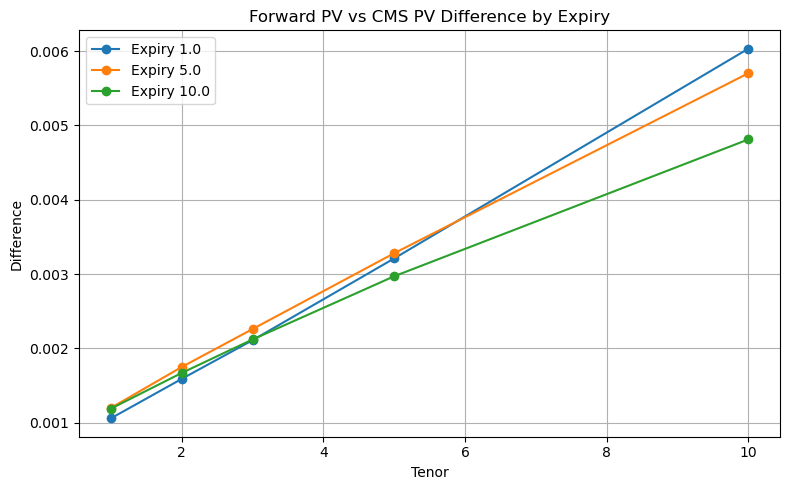

In [46]:
plot_df = pd.concat(
    [
        sabr_calibration_results[['Expiry', 'Tenor']],
        tabulate_forwards_and_CMS_PVs(sabr_calibration_results, ois_discount_factors)
    ],
    axis=1
).sort_values(['Expiry', 'Tenor'])

fig, ax = plt.subplots(figsize=(8, 5))

for expiry, grp in plot_df.groupby('Expiry'):
    ax.plot(grp['Tenor'], grp['Difference'], marker='o', label=f'Expiry {expiry}')

ax.set_xlabel('Tenor')
ax.set_ylabel('Difference')
ax.set_title('Forward PV vs CMS PV Difference by Expiry')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()